In [2]:
import numpy as np
import pandas as pd
import sklearn
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report,accuracy_score
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from pylab import rcParams
rcParams['figure.figsize'] = 14, 8
RANDOM_SEED = 42
LABELS = ["Normal", "Fraud"]

In [3]:
from google.colab import files
upload = files.upload()

Saving creditcard.csv to creditcard.csv


In [4]:
data = pd.read_csv('creditcard.csv',sep=',')
data.head()

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,15776156,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,15739548,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,15662854,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,15687688,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,15715750,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  690 non-null    int64  
 1   A1          690 non-null    int64  
 2   A2          690 non-null    float64
 3   A3          690 non-null    float64
 4   A4          690 non-null    int64  
 5   A5          690 non-null    int64  
 6   A6          690 non-null    int64  
 7   A7          690 non-null    float64
 8   A8          690 non-null    int64  
 9   A9          690 non-null    int64  
 10  A10         690 non-null    int64  
 11  A11         690 non-null    int64  
 12  A12         690 non-null    int64  
 13  A13         690 non-null    int64  
 14  A14         690 non-null    int64  
 15  Class       690 non-null    int64  
dtypes: float64(3), int64(13)
memory usage: 86.4 KB


In [6]:
data.isnull().values.any()

np.False_

/tmp/ipykernel_2117/351607490.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes = pd.value_counts(data['Class'], sort = True)


Text(0, 0.5, 'Frequency')

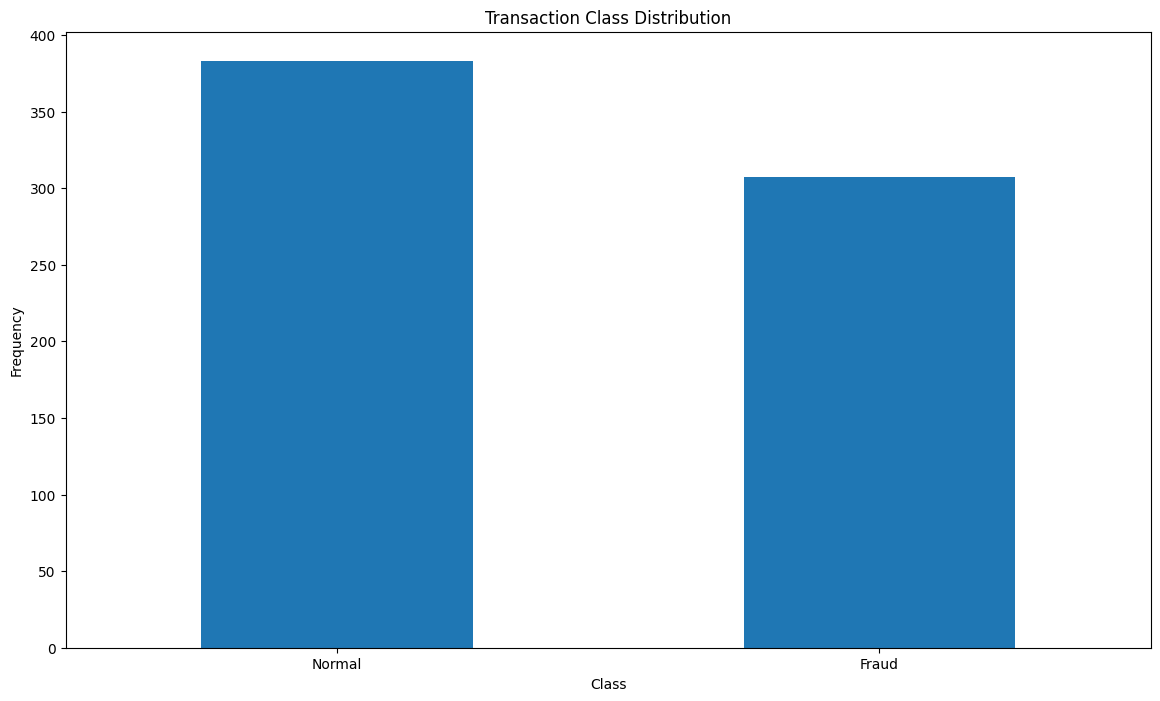

In [7]:
count_classes = pd.value_counts(data['Class'], sort = True)
count_classes.plot(kind = 'bar', rot=0)
plt.title("Transaction Class Distribution")
plt.xticks(range(2), LABELS)
plt.xlabel("Class")
plt.ylabel("Frequency")

In [8]:
fraud = data[data['Class']==1]
normal = data[data['Class']==0]
print(fraud.shape,normal.shape)

(307, 16) (383, 16)


In [11]:
fraud.A3.describe()

,A3
count,307.000000
mean,5.904951
std,5.471485
min,0.000000
25%,1.500000
50%,4.460000
75%,9.520000
max,28.000000


In [12]:
normal.A3.describe()

,A3
count,383.000000
mean,3.839948
std,4.337662
min,0.000000
25%,0.835000
50%,2.210000
75%,5.000000
max,26.335000


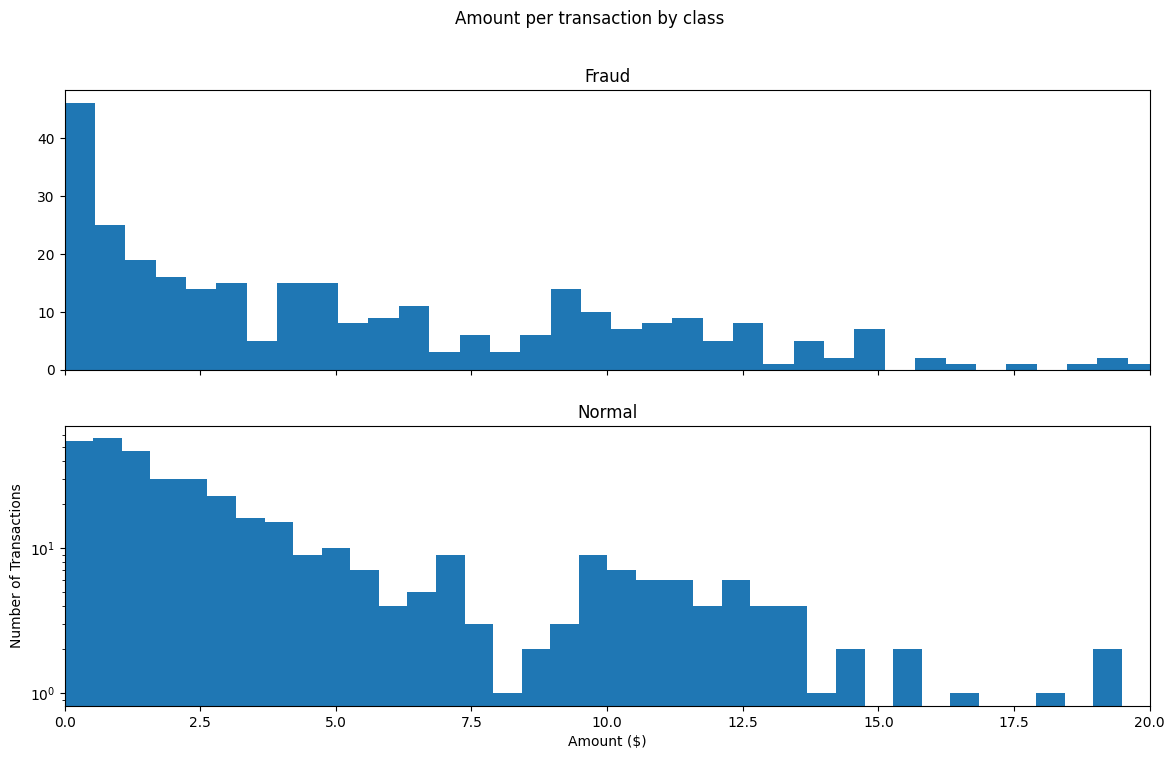

In [14]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Amount per transaction by class')
bins = 50
ax1.hist(fraud.A3,bins = bins)
ax1.set_title('Fraud')
ax2.hist(normal.A3,bins = bins)
ax2.set_title('Normal')
plt.xlabel('Amount ($)')
plt.ylabel('Number of Transactions')
plt.xlim((0,20))
plt.yscale('log')
plt.show();

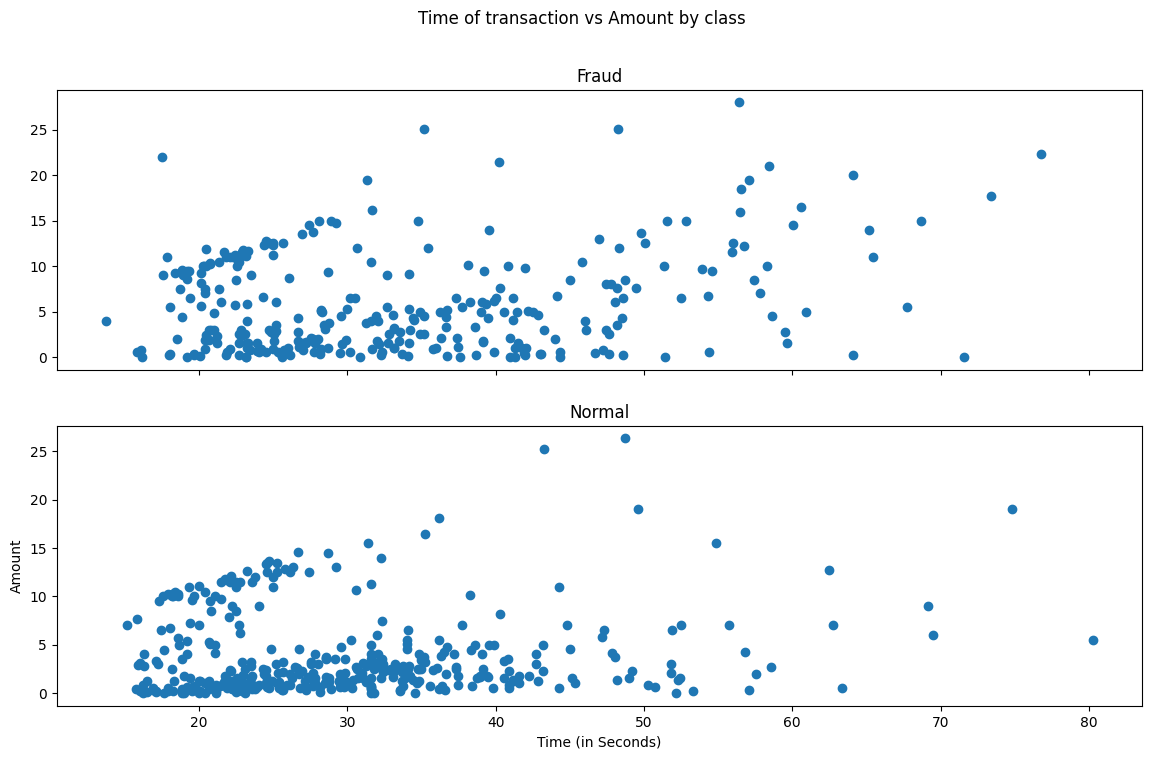

In [16]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Time of transaction vs Amount by class')
ax1.scatter(fraud.A2, fraud.A3)
ax1.set_title('Fraud')
ax2.scatter(normal.A2, normal.A3)
ax2.set_title('Normal')
plt.xlabel('Time (in Seconds)')
plt.ylabel('Amount')
plt.show()

In [17]:
data= data.sample(frac = 0.1,random_state=1)
data.shape

(69, 16)

In [18]:
Fraud = data[data['Class']==1]
Valid = data[data['Class']==0]
outlier_fraction = len(Fraud)/float(len(Valid))
print(outlier_fraction)
print("Fraud Cases : {}".format(len(Fraud)))
print("Valid Cases : {}".format(len(Valid)))

1.2258064516129032
Fraud Cases : 38
Valid Cases : 31


In [19]:
import seaborn as sns

In [20]:
corrmat = data.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(20,20))

<Figure size 2000x2000 with 0 Axes>

<Figure size 2000x2000 with 0 Axes>

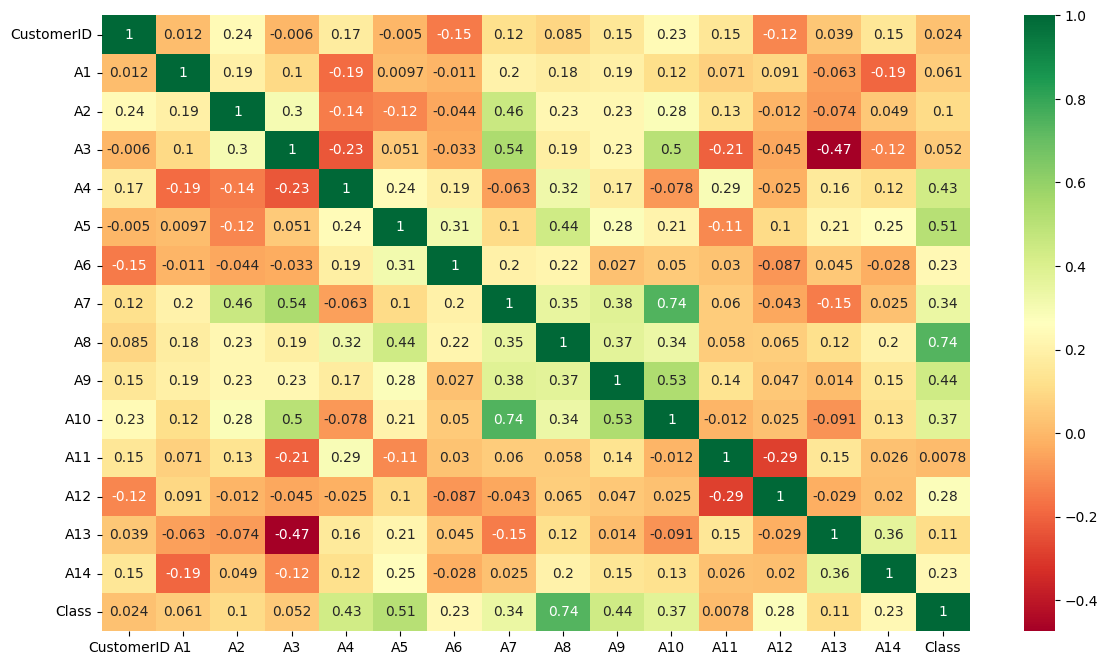

In [21]:
g=sns.heatmap(data[top_corr_features].corr(),annot=True,cmap="RdYlGn")

In [22]:
columns = data.columns.tolist()

In [23]:
columns = [c for c in columns if c not in ["Class"]]
target = "Class"

In [25]:
state = np.random.RandomState(42)
X = data[columns]
Y = data[target]
X_outliers = state.uniform(low=0, high=1,
size=(X.shape[0],X.shape[1]))

In [26]:
print(X.shape)
print(Y.shape)

(69, 15)
(69,)


In [28]:
classifiers = {
    "Isolation Forest": IsolationForest(
        n_estimators=100,
        max_samples=len(X),
        contamination=outlier_fraction,
        random_state=state,
        verbose=0
),
   "Local Outlier Factor": LocalOutlierFactor(
       n_neighbors=20,
       algorithm='auto',
       leaf_size=30,
       metric='minkowski',
       p=2,
       metric_params=None,
       contamination=outlier_fraction
    )
}

In [29]:
type(classifiers)
n_outliers = len(Fraud)

In [37]:
for clf_name, clf in classifiers.items():

    if clf_name == "Local Outlier Factor":
        y_pred = clf.fit_predict(X)
    else:
        clf.fit(X)
        y_pred = clf.predict(X)

    y_pred[y_pred == 1] = 0
    y_pred[y_pred == -1] = 1

    n_errors = (y_pred != Y).sum()

    print(f"{clf_name}: {n_errors}")
    print("Accuracy Score :")
    print(accuracy_score(Y, y_pred))

    print("Classification Report :")
    print(classification_report(Y, y_pred))

Isolation Forest: 34
Accuracy Score :
0.5072463768115942
Classification Report :
              precision    recall  f1-score   support

           0       0.46      0.52      0.48        31
           1       0.56      0.50      0.53        38

    accuracy                           0.51        69
   macro avg       0.51      0.51      0.51        69
weighted avg       0.51      0.51      0.51        69

Local Outlier Factor: 36
Accuracy Score :
0.4782608695652174
Classification Report :
              precision    recall  f1-score   support

           0       0.43      0.48      0.45        31
           1       0.53      0.47      0.50        38

    accuracy                           0.48        69
   macro avg       0.48      0.48      0.48        69
weighted avg       0.48      0.48      0.48        69

